# 📝 Control N° 1: Pipelines y Baselines

**Curso:** Machine Learning Supervisado - PECD UNI  
**Docente:** Jordan King Rodriguez Mallqui  
**Estudiante:** [COMPLETA TUS APELLIDOS Y NOMBRES AQUÍ]  
**Modalidad:** Individual

---

## 1. Introducción y Contexto del Negocio

El dataset seleccionado es el **Adult Income Dataset** (también conocido como Census Income), que contiene información demográfica extraída de la base de datos del censo de 1994 en Estados Unidos.

**Variable Objetivo (Target):** `income`
- Es un problema de **clasificación binaria**.
- El objetivo es predecir si los ingresos anuales de una persona superan los \$50,000 dólares al año o no (`>50K` o `<=50K`).

**Pregunta de Negocio:**
¿Qué características demográficas o laborales son los mejores indicadores para identificar si una persona tiene ingresos anuales altos (superiores a \$50,000)? Esto puede ser útil para campañas de marketing dirigidas o para ofrecer productos financieros premium a clientes potenciales con mayor capacidad adquisitiva.

## 2. Carga y Exploración de Datos (EDA)

Primero, importamos las librerías necesarias y cargamos el dataset desde una fuente pública.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuraciones de visualización
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [20]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num", 
    "marital-status", "occupation", "relationship", "race", 
    "sex", "capital-gain", "capital-loss", "hours-per-week", 
    "native-country", "income"
]
df = pd.read_csv(url, names=columns, na_values=" ?", skipinitialspace=True)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [21]:
# Análisis descriptivo básico
print("Shape del dataset:", df.shape)
print("\nTipos de datos y nulos:")
df.info()

Shape del dataset: (32561, 15)

Tipos de datos y nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


### Gráficos Exploratorios
Analizaremos la distribución de nuestro target y cómo se relaciona con otras variables importantes como la edad y la clase laboral.

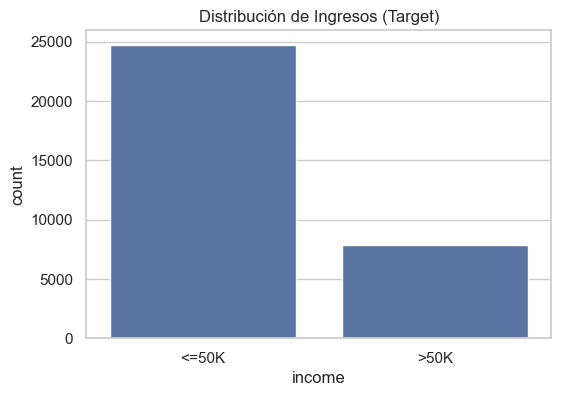

Proporción de clases:
 income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64


In [22]:
# Distribución de la variable objetivo
plt.figure(figsize=(6, 4))
sns.countplot(x='income', data=df)
plt.title('Distribución de Ingresos (Target)')
plt.show()

print("Proporción de clases:\n", df['income'].value_counts(normalize=True))

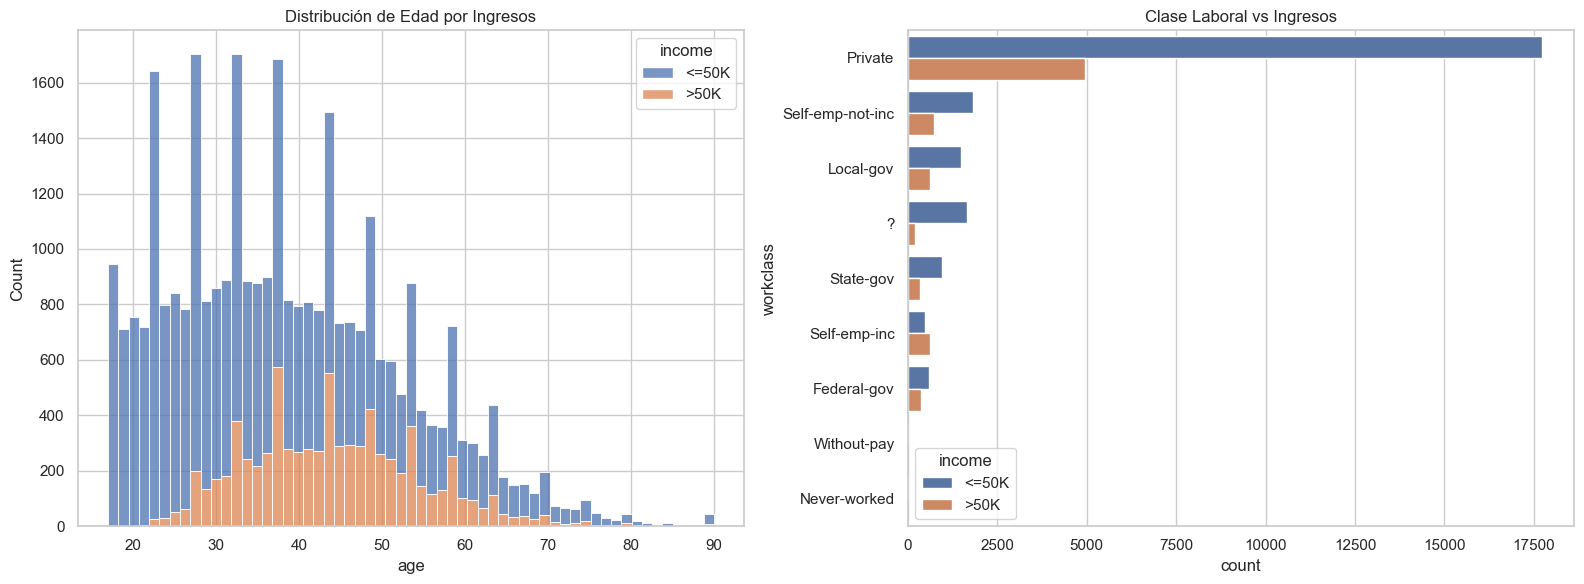

In [23]:
# Relación de variables independientes con el target
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Edad vs Ingresos
sns.histplot(data=df, x='age', hue='income', multiple='stack', ax=axes[0])
axes[0].set_title('Distribución de Edad por Ingresos')

# Gráfico 2: Clase Laboral vs Ingresos
sns.countplot(data=df, y='workclass', hue='income', ax=axes[1], order=df['workclass'].value_counts().index)
axes[1].set_title('Clase Laboral vs Ingresos')

plt.tight_layout()
plt.show()

**Interpretación EDA:**
- El dataset está desbalanceado (aprox 76% gana <=50K y 24% gana >50K).
- A medida que aumenta la edad, parece haber una mayor proporción de personas ganando >50K (al menos hasta los 50 años).
- En el sector privado ('Private') se encuentra la mayor cantidad de personas, seguido por 'Self-emp-not-inc'.

## 3. Preprocesamiento con Pipeline

Para evitar **Data Leakage**, vamos a separar nuestro dataset en Entrenamiento (Train) y Prueba (Test) **antes** de aplicar cualquier tipo de transformación.

In [24]:
from sklearn.model_selection import train_test_split

# Separar features (X) y target (y)
X = df.drop('income', axis=1)
y = df['income']

# Split 80% train, 20% test. Se usa random_state para reproducibilidad.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (26048, 14)
X_test shape: (6513, 14)


### Construcción del ColumnTransformer

Crearemos transformaciones específicas para variables numéricas y categóricas.

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identificar variables numéricas y categóricas
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

# Pipeline para variables numéricas (imputación con mediana + escalado)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variables categóricas (imputación con moda + codificación)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Ensamblaje en el ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

## 4. Modelo Baseline y Pipelines Finales

Implementaremos dos modelos baseline: uno ingenuo o "dummy", y una Regresión Logística básica como modelo simple a vencer.

In [26]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

# 1. Pipeline para Modelo Dummy (predice la clase mayoritaria siempre)
dummy_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='prior', random_state=42))
])

# 2. Pipeline para Modelo Simple (Regresión Logística)
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Entrenamiento de ambos pipelines
dummy_pipeline.fit(X_train, y_train)
logreg_pipeline.fit(X_train, y_train)

print("Modelos entrenados correctamente.")

Modelos entrenados correctamente.


## 5. Evaluación y Métricas

Ahora evaluamos el desempeño de ambos modelos en el conjunto de Test e incluimos gráficos comparativos para entender mejor los resultados.

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Predicciones
y_pred_dummy = dummy_pipeline.predict(X_test)
y_pred_logreg = logreg_pipeline.predict(X_test)

# Como el target es un string ('<=50K', '>50K'), debemos definir la clase positiva
pos_label = '>50K'

def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    rec = recall_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    return {'Modelo': model_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

metrics_dummy = evaluate_model(y_test, y_pred_dummy, 'Dummy Baseline')
metrics_logreg = evaluate_model(y_test, y_pred_logreg, 'Logistic Regression')

df_metrics = pd.DataFrame([metrics_dummy, metrics_logreg])
df_metrics

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Dummy Baseline,0.759251,0.000000,0.000000,0.000000
1,Logistic Regression,0.855980,0.739726,0.619898,0.674532


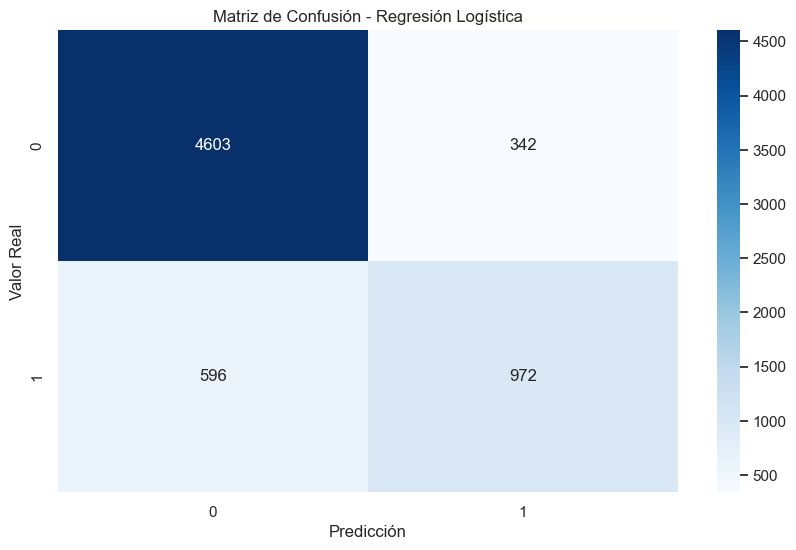


Reporte de Clasificación (Logistic Regression):

              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      4945
        >50K       0.74      0.62      0.67      1568

    accuracy                           0.86      6513
   macro avg       0.81      0.78      0.79      6513
weighted avg       0.85      0.86      0.85      6513



In [28]:
# Matriz de Confusión para el modelo LogReg
cm = confusion_matrix(y_test, y_pred_logreg)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

print("\nReporte de Clasificación (Logistic Regression):\n")
print(classification_report(y_test, y_pred_logreg))

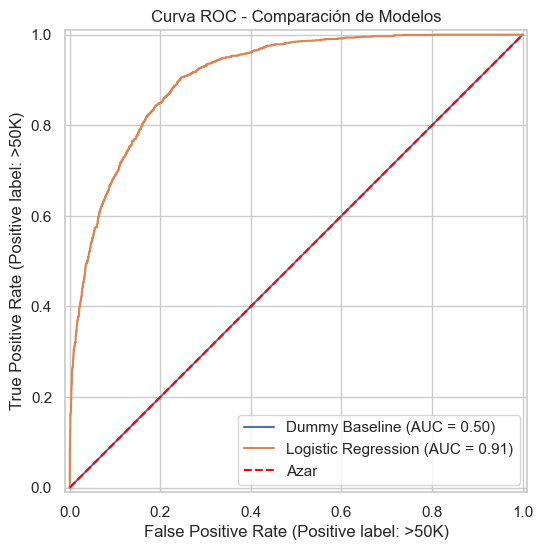

In [29]:
from sklearn.metrics import RocCurveDisplay

# Curva ROC para comparar el poder discriminatorio
plt.figure(figsize=(8, 6))
ax = plt.gca()
RocCurveDisplay.from_estimator(dummy_pipeline, X_test, y_test, ax=ax, name='Dummy Baseline')
RocCurveDisplay.from_estimator(logreg_pipeline, X_test, y_test, ax=ax, name='Logistic Regression')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Azar')
plt.title('Curva ROC - Comparación de Modelos')
plt.legend()
plt.show()

### Importancia de las Variables (Feature Importance)
Para la regresión logística, podemos inspeccionar qué variables tuvieron el mayor impacto (ya sea positivo o negativo) para predecir si la persona gana más de 50K.

C:\Users\Theki\AppData\Local\Temp\ipykernel_27568\1022091701.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='vlag')


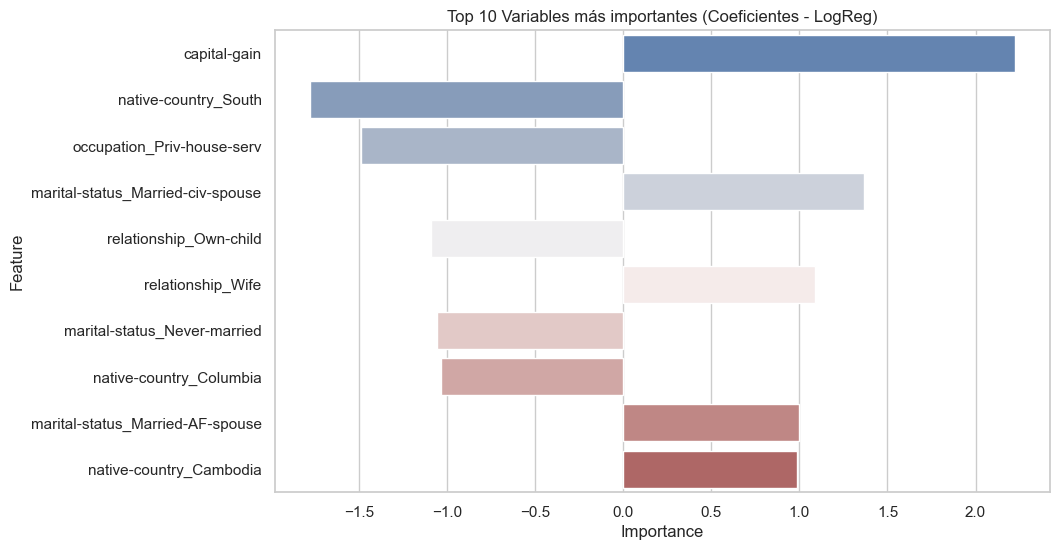

In [30]:
# Extraer coeficientes del modelo de Regresión Logística
classifier = logreg_pipeline.named_steps['classifier']
preprocessor = logreg_pipeline.named_steps['preprocessor']

# Obtener nombres de las variables después del preprocesamiento
cat_features = preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features)
all_features = list(numeric_features) + list(cat_features)

# Obtener coeficientes y crear dataframe
coefficients = classifier.coef_[0]
feature_importance = pd.DataFrame({'Feature': all_features, 'Importance': coefficients})

# Seleccionar el Top 10 de variables más influyentes (por magnitud)
feature_importance['Abs_Importance'] = feature_importance['Importance'].abs()
top_features = feature_importance.sort_values(by='Abs_Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='vlag')
plt.title('Top 10 Variables más importantes (Coeficientes - LogReg)')
plt.show()

## 6. Conclusiones

1. **¿El baseline es suficiente?**
   - El modelo Dummy obtuvo una Accuracy de ~75.9%, que refleja solo predecir la clase mayoritaria. Su F1-Score para la clase positiva (`>50K`) es 0%. Como se vio en la curva ROC, este modelo equivale a lanzar una moneda sesgada o a no tener poder discriminatorio (AUC = 0.5).
   - El modelo simple de Regresión Logística supera ampliamente al baseline con un Accuracy >85% y un F1-Score aceptable (~0.66). Además, la Curva ROC muestra que el modelo tiene una gran capacidad discriminatoria respecto al azar (AUC cercano a 0.90).

2. **Insights del Negocio (Gráficos y Feature Importance):**
   - En el EDA vimos que ganar >50K está asociado con la edad (personas mayores tienden a ganar más).
   - El gráfico de importancia de variables confirma que el **estado civil** (Married-civ-spouse) y variables financieras (capital-gain) tienen un peso muy positivo para predecir altos ingresos.

3. **Próximos pasos sugeridos:**
   - Experimentar con modelos basados en árboles (Random Forest, XGBoost) que puedan capturar relaciones no lineales en edad y ocupación de mejor manera.
   - Realizar Feature Engineering: agrupar los países de origen ('native-country') en categorías más simples para reducir la cardinalidad, o agrupar los estados civiles.